In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from src.data_processing import clean_raw_data
from src.modeling import train_final_model
from src.explainability import (shap_explainer, plot_global_shap_summary, generate_adverse_action_notice, get_explanation)

In [3]:
df_raw = pd.read_csv("../data/raw/credit_risk_dataset.csv")
cleaned_data = clean_raw_data(df_raw)

num_cols_b = ["person_age", "person_income", "person_emp_length", "loan_amnt", "loan_percent_income", "cb_person_cred_hist_length"]
cat_cols_b = ["person_home_ownership", "loan_intent", "cb_person_default_on_file"]

final_model, final_preprocessor = train_final_model(cleaned_data, num_cols_b, cat_cols_b)
X = cleaned_data[num_cols_b + cat_cols_b]
X_trans = final_preprocessor.transform(X)

print(f"Model trained! X_trans shape: {X_trans.shape}")

Model trained! X_trans shape: (32416, 18)


In [4]:
feature_names = final_preprocessor.get_feature_names_out()
clean_feature_names = [name.split('__')[-1] for name in feature_names]
print("Features are ready for SHAP:")
print(clean_feature_names)

Features are ready for SHAP:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'cb_person_default_on_file_N', 'cb_person_default_on_file_Y']


In [5]:
explainer, shap_values = shap_explainer(final_model, X_trans)
print("SHAP values calculated successfully!")

SHAP values calculated successfully!


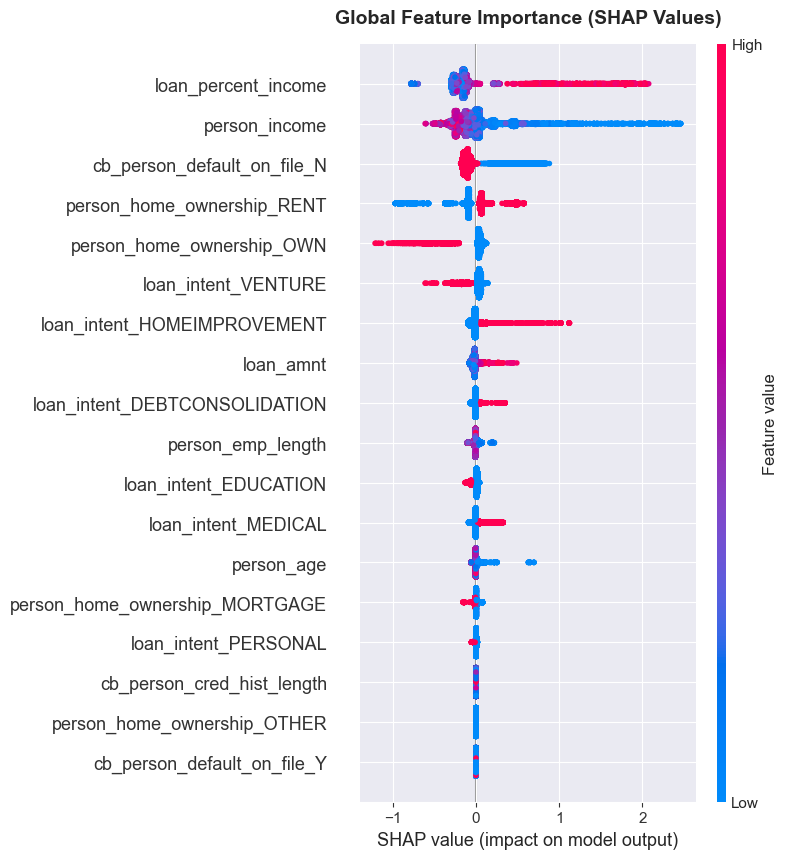

In [6]:
plot_global_shap_summary(shap_values, feature_names=clean_feature_names)

In [7]:

# 1. Словарь для перевода технических колонок в красивый текст
FEATURE_MAPPING = {
    "person_age": "Applicant Age",
    "person_income": "Annual Income",
    "person_emp_length": "Employment Length (years)",
    "loan_amnt": "Requested Loan Amount",
    "loan_percent_income": "Loan-to-Income Ratio",
    "cb_person_cred_hist_length": "Credit History Length",
    "person_home_ownership_RENT": "Home Ownership: Renting",
    "person_home_ownership_OWN": "Home Ownership: Owned",
    "person_home_ownership_MORTGAGE": "Home Ownership: Mortgage",
    "loan_intent_VENTURE": "Loan Purpose: Venture",
    "loan_intent_MEDICAL": "Loan Purpose: Medical",
    "cb_person_default_on_file_Y": "Historical Default: Yes",
    "cb_person_default_on_file_N": "Historical Default: No"
}

client_index = 10

detailed_text = get_explanation(
    shap_values=shap_values,
    sample_index=client_index,
    feature_names=clean_feature_names,
    X_display=X,
    reason_map=FEATURE_MAPPING,
    top_n=4
)

print("[STREAMLIT UI TEXT PREVIEW]")
print(detailed_text)

[STREAMLIT UI TEXT PREVIEW]
The baseline default risk for an average applicant is 19.3%. For this specific applicant, the model calculated a default risk of 71.4%.

The main factors behind this score were:
- Applicant Age (value: 22) slightly increased the risk score
- Annual Income (value: 85000) slightly decreased the risk score
- Employment Length (years) (value: 6.0) slightly decreased the risk score
- Requested Loan Amount (value: 35000) slightly increased the risk score
